In [1]:
seed=42

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [11]:
#loading data
df = pd.read_csv("data/processed/processed_df.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [5]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.dtypes

gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [12]:
for col in df.columns:
    if df[col].dtype=='object':
        print(f"{col}---------->({df[col].unique()})")

gender---------->(['Female' 'Male'])
SeniorCitizen---------->(['no' 'yes'])
Partner---------->(['Yes' 'No'])
Dependents---------->(['No' 'Yes'])
PhoneService---------->(['No' 'Yes'])
MultipleLines---------->(['No phone service' 'No' 'Yes'])
InternetService---------->(['DSL' 'Fiber optic' 'No'])
OnlineSecurity---------->(['No' 'Yes' 'No internet service'])
OnlineBackup---------->(['Yes' 'No' 'No internet service'])
DeviceProtection---------->(['No' 'Yes' 'No internet service'])
TechSupport---------->(['No' 'Yes' 'No internet service'])
StreamingTV---------->(['No' 'Yes' 'No internet service'])
StreamingMovies---------->(['No' 'Yes' 'No internet service'])
Contract---------->(['Month-to-month' 'One year' 'Two year'])
PaperlessBilling---------->(['Yes' 'No'])
PaymentMethod---------->(['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)'])


In [8]:
df.dtypes

gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [9]:
df.isna().sum(), df.shape

(gender              0
 SeniorCitizen       0
 Partner             0
 Dependents          0
 tenure              0
 PhoneService        0
 MultipleLines       0
 InternetService     0
 OnlineSecurity      0
 OnlineBackup        0
 DeviceProtection    0
 TechSupport         0
 StreamingTV         0
 StreamingMovies     0
 Contract            0
 PaperlessBilling    0
 PaymentMethod       0
 MonthlyCharges      0
 TotalCharges        0
 Churn               0
 dtype: int64,
 (7032, 20))

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   object 
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 


# FEATURE ENGINEERING

In [ ]:
# df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

### saving processed data

In [ ]:
# import os

# # create directory if it doesn't exist
# os.makedirs("data/processed", exist_ok=True)

# # save dataframe
# df.to_csv("data/processed/processed_df1.csv", index=False)

In [15]:
df.head(1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0


In [16]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [17]:
X.shape, y.shape

((7032, 19), (7032,))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seed
)

function to save experiment metrics into csv file

In [ ]:
import pandas as pd
import os
from datetime import datetime

def log_experiment(
    model_name,
    X_train,
    classification_rep,
    roc_auc,
    features_desc,
    hyperparameters="default",
    imbalance_handling="None",
    notes="",
    file_path="experiment_log.csv"
):
    
    # Generate experiment ID
    if os.path.exists(file_path):
        df_old = pd.read_csv(file_path)
        exp_id = f"exp_{len(df_old)+1:03d}"
    else:
        df_old = None
        exp_id = "exp_001"
    
    # Extract metrics from classification report
    metrics = {
        "experiment_id": exp_id,
        "timestamp": datetime.now(),
        "model": model_name,
        "features": features_desc,
        "feature_count": X_train.shape[1],
        "imbalance_handling": imbalance_handling,
        "hyperparameters": hyperparameters,
        
        "roc_auc": roc_auc,
        
        # Class 0
        "precision_0": classification_rep["0"]["precision"],
        "recall_0": classification_rep["0"]["recall"],
        "f1_0": classification_rep["0"]["f1-score"],
        
        # Class 1
        "precision_1": classification_rep["1"]["precision"],
        "recall_1": classification_rep["1"]["recall"],
        "f1_1": classification_rep["1"]["f1-score"],
        
        "notes": notes
    }
    
    df_new = pd.DataFrame([metrics])
    
    # Save or append
    if df_old is None:
        df_new.to_csv(file_path, index=False)
    else:
        df_final = pd.concat([df_old, df_new], ignore_index=True)
        df_final.to_csv(file_path, index=False)
    
    print(f"✅ Experiment {exp_id} logged successfully!")

Baseline Model

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [col for col in X.columns if col not in num_cols]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [ ]:
pipeline.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

logging result metrics into csv

In [ ]:
# Metrics
report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, y_prob)

# Log
log_experiment(
    model_name="Logistic Regression(baseline)",
    X_train=X_train,
    classification_rep=report,
    roc_auc=roc_auc,
    features_desc="base(encoded features)",
    hyperparameters="default",
    notes="Clean baseline with just encoding features"
)

In [ ]:
import pandas as pd
exp_log= pd.read_csv("experiment_log.csv")
exp_log

### FEATURE ENGINEERING PART 2

In [ ]:
services = ['PhoneService','MultipleLines','InternetService',
            'OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies']

X_train['NumServices'] = (X_train[services] == 'Yes').sum(axis=1)
X_test['NumServices'] = (X_test[services] == 'Yes').sum(axis=1)

In [ ]:
X_train.head(4)

modelling baseline with Numservices as a feature

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges','NumServices']
cat_cols = [col for col in X.columns if col not in num_cols]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [ ]:
report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, y_prob)

# Log
log_experiment(
    model_name="Logistic Regression(baseline)",
    X_train=X_train,
    classification_rep=report,
    roc_auc=roc_auc,
    features_desc="basic+ number of services",
    hyperparameters="default",
    notes="baseline with num of services engineered feature"
)

In [ ]:
import pandas as pd
exp_log= pd.read_csv("experiment_log.csv")
exp_log

## trying with Segment labels

In [26]:
df = pd.read_csv("data/processed/df_with_segment_labels.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,segment,segment_label
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,Low Engagement ⚠️
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2,Stable Mid-Value 👍
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,2,Stable Mid-Value 👍
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2,Stable Mid-Value 👍
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,3,At risk High-value 🚨


In [27]:
X = df.drop(['Churn','segment_label'], axis=1)
y = df['Churn']

In [28]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,segment
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,1
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,2
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,2
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,2
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,3


In [29]:
X.shape, y.shape

((7032, 20), (7032,))

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seed
)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [col for col in X.columns if col not in num_cols]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.64      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.80      1407

ROC-AUC: 0.8339567015752882


In [32]:
report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, y_prob)

# Log
log_experiment(
    model_name="Logistic (baseline)",
    X_train=X_train,
    classification_rep=report,
    roc_auc=roc_auc,
    features_desc="base + segment labels",
    hyperparameters="default",
    notes="trained on (df_with_segment_label.csv)"
)

import pandas as pd
exp_log= pd.read_csv("experiment_log.csv")
exp_log

✅ Experiment exp_005 logged successfully!


,experiment_id,timestamp,model,features,feature_count,imbalance_handling,hyperparameters,roc_auc,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,notes
0,exp_001,2026-04-05 20:56:36.571349,Logistic (baseline),base(encoded features),19,NaN,default,0.836071,0.851577,0.888674,0.869730,0.650456,0.572193,0.608819,Clean baseline with just encoding features
1,exp_002,2026-04-06 20:38:36.518022,Logistic (baseline),base+ numberOfServices scaled,20,NaN,default,0.836007,0.852230,0.887706,0.869606,0.649547,0.574866,0.609929,baseline model with scaled num of services as ...
2,exp_003,2026-04-10 01:13:01.769019,Logistic (baseline),base + segment labels,20,NaN,default,0.835417,0.850277,0.890610,0.869976,0.652308,0.566845,0.606581,baseline with segment labels
3,exp_004,2026-04-11 12:59:15.247340,logistic,base + 12 engineered,31,NaN,NaN,0.833304,0.838828,0.886738,0.862118,0.628571,0.529412,0.574746,trained on (base_plus_engineered.csv)
4,exp_005,2026-04-11 13:16:56.911720,Logistic (baseline),base + segment labels,20,NaN,default,0.833957,0.848148,0.886738,0.867014,0.642202,0.561497,0.599144,trained on (df_with_segment_label.csv)


## with engineered features

In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)

df = pd.read_csv("data/processed/base_plus_engineered.csv")
df.shape

(7032, 32)

In [4]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,avg_monthly_spend,charge_gap,is_high_value,tenure_band,streaming_count,security_count,month_to_month_paperless,payment_electronic_check,no_support_services,is_isolated,fiber_no_security,no_internet_services
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.850000,0.000000,0,0-12,0,1,1,1,1,0,0,0
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,55.573529,1.376471,0,12-36,0,2,0,0,0,1,0,0
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,54.075000,-0.225000,0,0-12,0,2,1,0,0,1,0,0
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.905556,1.394444,0,36+,0,3,0,0,0,1,0,0
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,75.825000,-5.125000,1,0-12,0,0,1,1,1,1,1,0


In [5]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'avg_monthly_spend',
       'charge_gap', 'is_high_value', 'tenure_band', 'streaming_count',
       'security_count', 'month_to_month_paperless',
       'payment_electronic_check', 'no_support_services', 'is_isolated',
       'fiber_no_security', 'no_internet_services'],
      dtype='object')

In [7]:
num_cols = [
    'tenure', 
    'MonthlyCharges', 
    'TotalCharges',
    'avg_monthly_spend',
    'charge_gap',
    'streaming_count',
    'security_count'
]
len(num_cols)


7

In [8]:
binary_cols = [
    'month_to_month_paperless',
    'payment_electronic_check',
    'no_support_services',
    'is_isolated',
    'fiber_no_security',
    'no_internet_services',
    'is_high_value'
]
len(binary_cols)

7

In [9]:
cat_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'tenure_band','SeniorCitizen'
]
len(cat_cols)

17

modelling

In [10]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']

In [11]:
X.shape, y.shape

((7032, 31), (7032,))

In [12]:
seed=42

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seed
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('bin', 'passthrough', binary_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407

ROC-AUC: 0.8333044297539485


In [15]:
from experiment_logger import log_experiment

report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, y_prob)
# Log
log_experiment(
    model_name="logistic",
    X_train=X_train,
    classification_rep=report,
    roc_auc=roc_auc,
    features_desc="base + 12 engineered",
    hyperparameters="",
    notes="trained on (base_plus_engineered.csv)"
)

import pandas as pd
exp_log= pd.read_csv("experiment_log.csv")
exp_log

✅ Experiment exp_004 logged successfully!


,experiment_id,timestamp,model,features,feature_count,imbalance_handling,hyperparameters,roc_auc,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,notes
0,exp_001,2026-04-05 20:56:36.571349,Logistic (baseline),base(encoded features),19,NaN,default,0.836071,0.851577,0.888674,0.869730,0.650456,0.572193,0.608819,Clean baseline with just encoding features
1,exp_002,2026-04-06 20:38:36.518022,Logistic (baseline),base+ numberOfServices scaled,20,NaN,default,0.836007,0.852230,0.887706,0.869606,0.649547,0.574866,0.609929,baseline model with scaled num of services as ...
2,exp_003,2026-04-10 01:13:01.769019,Logistic (baseline),base + segment labels,20,NaN,default,0.835417,0.850277,0.890610,0.869976,0.652308,0.566845,0.606581,baseline with segment labels
3,exp_004,2026-04-11 12:59:15.247340,logistic,base + 12 engineered,31,NaN,NaN,0.833304,0.838828,0.886738,0.862118,0.628571,0.529412,0.574746,trained on (base_plus_engineered.csv)


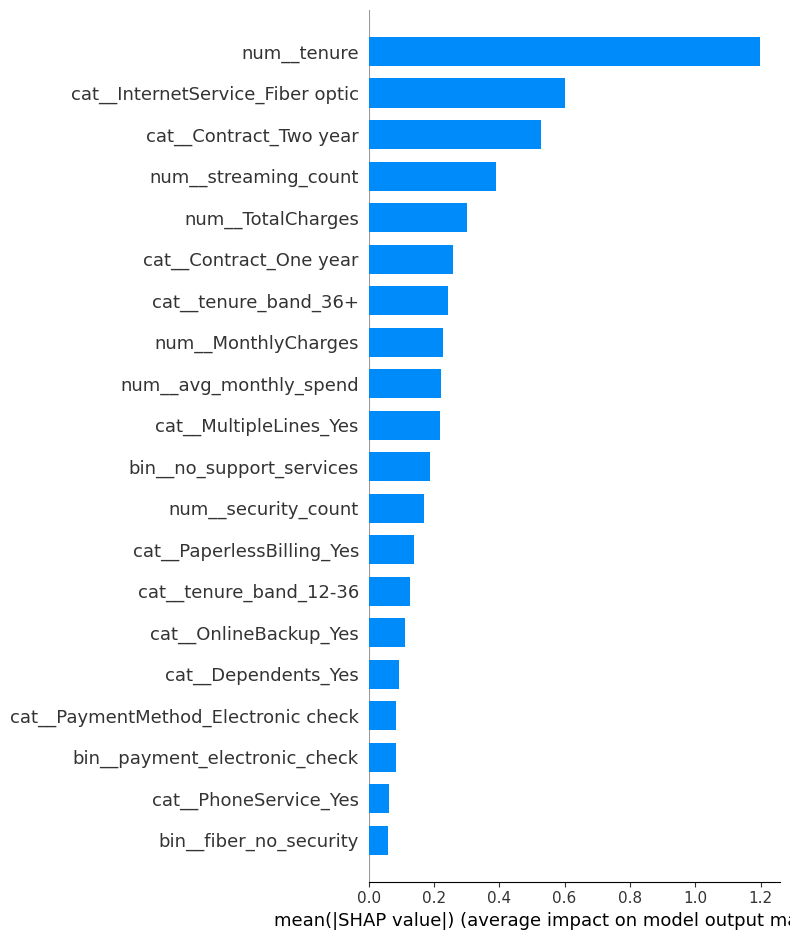

In [24]:
# Transform data
X_train_transformed = pipeline.named_steps['prep'].transform(X_train)
X_test_transformed = pipeline.named_steps['prep'].transform(X_test)

# Get model
model = pipeline.named_steps['model']

# SHAP
import shap

explainer = shap.LinearExplainer(model, X_train_transformed)
shap_values = explainer(X_test_transformed)  # modern SHAP

# Feature names
feature_names = pipeline.named_steps['prep'].get_feature_names_out()

# Plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type="bar")